In [1]:
#Phase 1: Graph Modeling of the Road Network

# Define a small road network as an undirected graph (adjacency list)
# Nodes are numbered 0 to 5 (intersections), edges have base travel costs.
base_graph = {
    0: {1: 2, 2: 2},          # Roads from node 0 to 1 and 0 to 2 with cost 2
    1: {0: 2, 2: 1, 3: 3},    # Roads from node 1 to 0, 2, 3
    2: {0: 2, 1: 1, 3: 2, 4: 5},
    3: {1: 3, 2: 2, 4: 2, 5: 3},
    4: {2: 5, 3: 2, 5: 2},
    5: {3: 3, 4: 2}
}
# Make a copy for current dynamic costs (which will change over time)
import copy
current_graph = copy.deepcopy(base_graph)

# For clarity, let's print the base graph structure
print("Base road network (adjacency list with costs):")
for u, neighbors in base_graph.items():
    print(f" Node {u}: {neighbors}")


Base road network (adjacency list with costs):
 Node 0: {1: 2, 2: 2}
 Node 1: {0: 2, 2: 1, 3: 3}
 Node 2: {0: 2, 1: 1, 3: 2, 4: 5}
 Node 3: {1: 3, 2: 2, 4: 2, 5: 3}
 Node 4: {2: 5, 3: 2, 5: 2}
 Node 5: {3: 3, 4: 2}


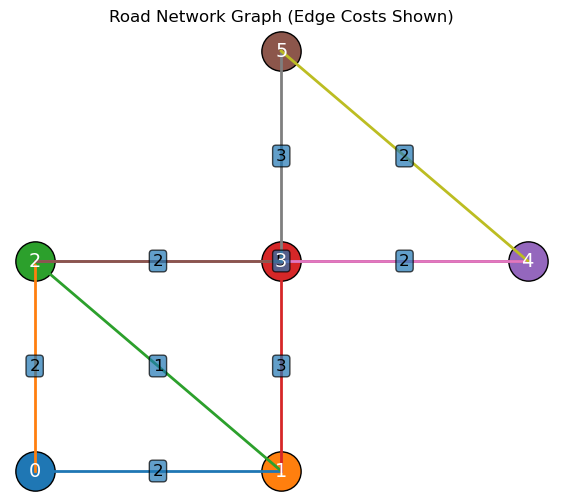

In [3]:
#Phase 1.1 : Graph visualization of road networks

import matplotlib.pyplot as plt

# --- Your graph ---
base_graph = {
    0: {1: 2, 2: 2},
    1: {0: 2, 2: 1, 3: 3},
    2: {0: 2, 1: 1, 3: 2, 4: 5},
    3: {1: 3, 2: 2, 4: 2, 5: 3},
    4: {2: 5, 3: 2, 5: 2},
    5: {3: 3, 4: 2}
}

# --- Manual coordinates for nodes (you can change these) ---
pos = {
    0: (0, 0),
    1: (2, 0),
    2: (0, 2),
    3: (2, 2),
    4: (4, 2),
    5: (2, 4),
}

plt.figure(figsize=(7, 6))

# --- Draw edges with cost labels ---
drawn = set()  # to avoid drawing undirected edges twice

for u in base_graph:
    for v, cost in base_graph[u].items():
        if (v, u) in drawn:
            continue
        drawn.add((u, v))

        x1, y1 = pos[u]
        x2, y2 = pos[v]

        # draw edge line
        plt.plot([x1, x2], [y1, y2], linewidth=2)

        # edge label at midpoint
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        plt.text(mx, my, str(cost), fontsize=12, ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.2", alpha=0.7))

# --- Draw nodes ---
for node, (x, y) in pos.items():
    plt.scatter(x, y, s=800, edgecolors='black')
    plt.text(x, y, str(node), fontsize=14, ha='center', va='center', color='white')

plt.title("Road Network Graph (Edge Costs Shown)")
plt.axis("off")
plt.show()


In [4]:


# Phase 2: Simulating Traffic Congestion with Random Data

import random

def update_costs(current_graph, base_graph, distribution='uniform'):
    """Update current_graph costs based on base_graph using random congestion factors."""
    for u in base_graph:
        for v in base_graph[u]:
            base_cost = base_graph[u][v]
            # Apply a random congestion factor
            if distribution == 'uniform':
                factor = random.uniform(0.5, 1.5)   # e.g., 50% to 150% of base cost
            elif distribution == 'normal':
                factor = random.gauss(1.0, 0.2)    # mean=1.0, std=0.2 (clamp if needed)
            else:
                factor = 1.0  # default, no change
            # Ensure factor is positive and within a reasonable range
            factor = max(0.1, min(factor, 3.0))
            current_graph[u][v] = base_cost * factor

# Example: update current_graph once with uniform distribution and print results
update_costs(current_graph, base_graph, distribution='uniform')
print("\nUpdated road costs after one congestion update:")
for u, neighbors in current_graph.items():
    print(f" Node {u}: {neighbors}")




Updated road costs after one congestion update:
 Node 0: {1: 2.986500820378141, 2: 2.3084754871496083}
 Node 1: {0: 1.1995699296036575, 2: 1.2332246802475921, 3: 3.3370520846885654}
 Node 2: {0: 2.676135458214726, 1: 0.5979939732431555, 3: 2.670560734699746, 4: 3.7365609116989145}
 Node 3: {1: 2.5954797034441697, 2: 2.9904558235093233, 4: 2.9893434735253868, 5: 3.316500141295389}
 Node 4: {2: 6.231580897552775, 3: 2.142187988037721, 5: 1.763560349400995}
 Node 5: {3: 1.9533494001139102, 4: 2.579624040772078}


In [8]:

# Phase 3: Implementing the Base Ant Colony Optimization (ACO)



def ant_colony_optimize(graph, start, goal, alpha=1.0, beta=2.0, rho=0.1, num_ants=5, iterations=10):
    """
    Run ACO on the given graph to find a path from start to goal.
    alpha: weight of pheromone influence, beta: weight of heuristic (1/cost),
    rho: pheromone evaporation rate, num_ants: number of ants per iteration,
    iterations: how many iterations (cycles of ants).
    Returns the best path and its cost.
    """
    # 1. Initialization: set initial pheromone on each edge
    tau = {}  # pheromone levels, keys are (u,v) pairs
    for u in graph:
        for v in graph[u]:
            tau[(u, v)] = 1.0  # initial pheromone (can be any constant)
    best_path = None
    best_cost = float('inf')
    
    # 2. Iteratively let ants construct solutions and update pheromones
    for it in range(iterations):
        paths_this_iter = []  # store paths found by ants in this iteration
        for k in range(num_ants):
            # Each ant starts at the start node and attempts to reach the goal
            current = start
            visited = {start}      # to avoid cycles, track visited nodes
            path = [start]
            cost = 0
            # Construct a path until the goal is reached or no moves possible
            while current != goal:
                neighbors = list(graph[current].keys())
                # Exclude visited neighbors to avoid immediate cycles
                choices = [j for j in neighbors if j not in visited]
                if not choices:  # no unvisited neighbor to go (dead-end)
                    path = None  # this ant's path fails/stops
                    break
                # Compute transition probabilities for each possible next node
                # based on pheromone and heuristic = 1/cost (desirability)
                total_pheromone = 0.0
                probs = []
                for j in choices:
                    # pheromone on edge (current, j)
                    pher = tau[(current, j)] ** alpha
                    # heuristic desirability (inverse of current road cost)
                    heuristic = (1.0 / graph[current][j]) ** beta
                    prob = pher * heuristic
                    probs.append((j, prob))
                    total_pheromone += prob
                # Randomly select the next node weighted by these probabilities (roulette wheel selection)
                r = random.random() * total_pheromone
                cum_sum = 0.0
                next_node = choices[-1]  # default to last choice
                for (j, prob) in probs:
                    cum_sum += prob
                    if r <= cum_sum:
                        next_node = j
                        break
                # Move to the chosen next node
                visited.add(next_node)
                path.append(next_node)
                cost += graph[current][next_node]
                current = next_node
                if current == goal:
                    break
            # If a full path to goal was constructed, record it
            if path is not None and current == goal:
                paths_this_iter.append((path, cost))
                if cost < best_cost:
                    best_cost = cost
                    best_path = path
        # 3. Pheromone Update: evaporate and reinforce
        # Evaporation: reduce pheromone on all edges
        for edge in tau:
            tau[edge] *= (1 - rho)
        # Reinforcement: for each ant path found, deposit pheromone on its edges
        for (path, cost) in paths_this_iter:
            # Deposit an amount inversely proportional to path cost (shorter path -> more pheromone)
            pheromone_deposit = 1.0 / cost if cost > 0 else 0
            # Add pheromone to each edge in the path (including reverse edge for undirected graph)
            for i in range(len(path) - 1):
                u = path[i]
                v = path[i+1]
                tau[(u, v)] += pheromone_deposit
                if (v, u) in tau:  # if undirected graph, also update opposite direction
                    tau[(v, u)] += pheromone_deposit
    return best_path, best_cost

# Quick test of ACO on the base graph from node 0 to 5
best_path, best_cost = ant_colony_optimize(base_graph, start=0, goal=5, alpha=1, beta=2, rho=0.1, num_ants=5, iterations=10)
print("\nACO best path on base graph:", best_path, "with cost", round(best_cost, 2))


ACO best path on base graph: [0, 2, 3, 4, 5] with cost 8


In [10]:

#  Phase 4: Integrating Particle Swarm Optimization (PSO) for Parameter Tuning


def pso_optimize_aco(graph, start, goal, swarm_size=10, iterations=20):
    """
    Use PSO to find good ACO parameters (alpha, beta, rho) for the given graph.
    Returns the best parameter tuple and its path cost.
    """
    # Parameter bounds
    alpha_range = (0.1, 5.0)
    beta_range  = (0.1, 5.0)
    rho_range   = (0.1, 0.9)
    # PSO constants
    w = 0.7    # inertia weight
    c1 = 1.5   # personal best influence
    c2 = 1.5   # global best influence
    
    # Initialize swarm with random positions and velocities
    particles = []
    for i in range(swarm_size):
        alpha = random.uniform(*alpha_range)
        beta  = random.uniform(*beta_range)
        rho   = random.uniform(*rho_range)
        # small initial velocity
        v_alpha = random.uniform(-0.1, 0.1)
        v_beta  = random.uniform(-0.1, 0.1)
        v_rho   = random.uniform(-0.1, 0.1)
        # Evaluate this particle (ACO run with few iterations for speed)
        _, cost = ant_colony_optimize(graph, start, goal, alpha, beta, rho, num_ants=3, iterations=5)
        particles.append({
            'pos': [alpha, beta, rho],
            'vel': [v_alpha, v_beta, v_rho],
            'pbest_pos': [alpha, beta, rho],
            'pbest_val': cost
        })
    # Initialize global best as best of personal bests
    gbest_particle = min(particles, key=lambda p: p['pbest_val'])
    gbest_pos = gbest_particle['pbest_pos'][:]  # best (alpha, beta, rho)
    gbest_val = gbest_particle['pbest_val']
    
    # PSO main loop
    for it in range(iterations):
        for p in particles:
            # Update velocity for each dimension (alpha, beta, rho)
            r1, r2 = random.random(), random.random()
            for d in range(3):
                # Velocity update formula: inertia + cognitive + social components
                p['vel'][d] = (w * p['vel'][d] 
                               + c1 * r1 * (p['pbest_pos'][d] - p['pos'][d]) 
                               + c2 * r2 * (gbest_pos[d]    - p['pos'][d]))
            # Update position and clamp within bounds
            p['pos'][0] += p['vel'][0];  p['pos'][0] = max(alpha_range[0], min(alpha_range[1], p['pos'][0]))
            p['pos'][1] += p['vel'][1];  p['pos'][1] = max(beta_range[0],  min(beta_range[1],  p['pos'][1]))
            p['pos'][2] += p['vel'][2];  p['pos'][2] = max(rho_range[0],   min(rho_range[1],   p['pos'][2]))
            # Evaluate new position
            _, cost = ant_colony_optimize(graph, start, goal, 
                                          alpha=p['pos'][0], beta=p['pos'][1], rho=p['pos'][2], 
                                          num_ants=3, iterations=5)
            # Update personal best if improvement
            if cost < p['pbest_val']:
                p['pbest_val'] = cost
                p['pbest_pos'] = p['pos'][:]
            # Update global best if improvement
            if cost < gbest_val:
                gbest_val = cost
                gbest_pos = p['pos'][:]
    return gbest_pos, gbest_val

# Run PSO to find best ACO parameters on the base graph
best_params, best_val = pso_optimize_aco(base_graph, start=0, goal=5, swarm_size=10, iterations=10)
best_alpha, best_beta, best_rho = best_params
print("\nPSO-tuned ACO parameters:", 
      f"alpha={best_alpha:.3f}, beta={best_beta:.3f}, rho={best_rho:.3f} (path cost={best_val:.2f})")




PSO-tuned ACO parameters: alpha=1.016, beta=1.107, rho=0.712 (path cost=7.00)


In [12]:

#  Phase 5: Dynamic Path Planning Simulation Over Time

# Use the tuned parameters (from PSO) for ACO
alpha_opt, beta_opt, rho_opt = best_alpha, best_beta, best_rho

# Simulate dynamic path planning for multiple time steps
T = 5  # number of time steps to simulate
dynamic_results = []  # to store results (path, cost) at each time step

print("\nDynamic path planning over time:")
for t in range(1, T+1):
    # Step 1: update traffic congestion (road costs)
    update_costs(current_graph, base_graph, distribution='uniform')
    # Step 2: run ACO with tuned parameters on the updated graph
    best_path_t, best_cost_t = ant_colony_optimize(current_graph, start=0, goal=5, 
                                                  alpha=alpha_opt, beta=beta_opt, rho=rho_opt, 
                                                  num_ants=5, iterations=10)
    dynamic_results.append((best_path_t, best_cost_t))
    # Print the best route and cost for this time step
    print(f" Time {t}: Best path = {best_path_t}, cost = {best_cost_t:.2f}")


Dynamic path planning over time:
 Time 1: Best path = [0, 2, 3, 5], cost = 7.25
 Time 2: Best path = [0, 2, 3, 4, 5], cost = 8.39
 Time 3: Best path = [0, 2, 4, 5], cost = 5.59
 Time 4: Best path = [0, 2, 3, 4, 5], cost = 7.30
 Time 5: Best path = [0, 1, 2, 3, 5], cost = 6.54


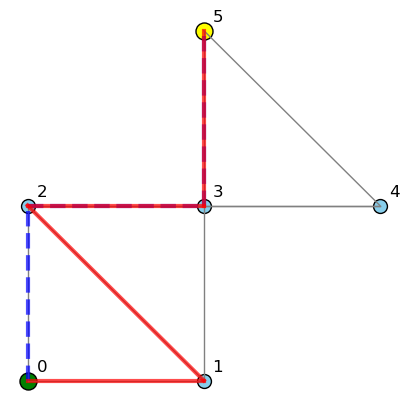

In [14]:

#  Phase 6: Visualization of Results (Optional)


import matplotlib.pyplot as plt

# (Using dynamic_results from Phase 5) 
# Take the initial best path and the final best path for visualization
initial_path = dynamic_results[0][0]
new_path = dynamic_results[-1][0]

# (Optional) Define coordinates for each node for plotting
coords = {
    0: (0, 0), 1: (2, 0), 2: (0, 2), 
    3: (2, 2), 4: (4, 2), 5: (2, 4)
}

plt.figure(figsize=(5,5))
# Draw all roads in the network
for u, neighbors in base_graph.items():
    for v, base_cost in neighbors.items():
        if u < v:  # ensure each undirected edge drawn once
            x_values = [coords[u][0], coords[v][0]]
            y_values = [coords[u][1], coords[v][1]]
            plt.plot(x_values, y_values, color='gray', linewidth=1)
# Highlight the initial optimal path
for i in range(len(initial_path)-1):
    u, v = initial_path[i], initial_path[i+1]
    plt.plot([coords[u][0], coords[v][0]], [coords[u][1], coords[v][1]],
             color='blue', linewidth=3, linestyle='--', alpha=0.7)
# Highlight the new optimal path after congestion changes
for i in range(len(new_path)-1):
    u, v = new_path[i], new_path[i+1]
    plt.plot([coords[u][0], coords[v][0]], [coords[u][1], coords[v][1]],
             color='red', linewidth=3, alpha=0.7)
# Draw nodes (intersections)
for node, (x, y) in coords.items():
    plt.scatter(x, y, s=100, color='skyblue', edgecolors='black')
    plt.text(x+0.1, y+0.1, str(node), fontsize=12)
# Highlight start and goal nodes
plt.scatter(coords[0][0], coords[0][1], s=150, color='green', edgecolors='black')  # start
plt.scatter(coords[5][0], coords[5][1], s=150, color='yellow', edgecolors='black') # goal
plt.axis('off')
plt.show()


In [16]:
# Phase 7: Correct Graph Model (store distance, C(t), R(t), ΔR)

import random
from dataclasses import dataclass

@dataclass
class Edge:
    d: float                 # fixed physical distance
    c: float = 0.0           # congestion coefficient C(t)
    R: float = 0.0           # road condition factor R(t)
    prev_R: float = 0.0      # previous R(t-1)

    def update_congestion(self, distribution="uniform"):
        # store previous R before updating
        self.prev_R = self.R

        # update congestion
        if distribution == "uniform":
            self.c = random.uniform(0.0, 1.0)
        elif distribution == "normal":
            val = random.gauss(0.5, 0.2)
            self.c = min(1.0, max(0.0, val))
        else:
            raise ValueError("distribution must be 'uniform' or 'normal'")

        # compute road condition factor R(t) = d * (1 + c)
        self.R = self.d * (1.0 + self.c)

    def delta_R(self):
        return abs(self.R - self.prev_R)


def build_edge_graph(base_graph):
    """
    Converts your base_graph (costs) into an edge-graph where
    base_graph cost is treated as distance d.
    """
    G = {}
    for u in base_graph:
        G[u] = {}
        for v, d in base_graph[u].items():
            G[u][v] = Edge(d=float(d))
            # initialize R at time 0 (c=0 => R=d)
            G[u][v].R = float(d)
            G[u][v].prev_R = float(d)
    return G


# build edge-based graph
edge_graph = build_edge_graph(base_graph)

# update congestion once and print edge info
for u in edge_graph:
    for v in edge_graph[u]:
        edge_graph[u][v].update_congestion("uniform")

print("Example edges after congestion update:")
for u in edge_graph:
    for v in edge_graph[u]:
        e = edge_graph[u][v]
        print(f"{u}->{v}: d={e.d:.2f}, c={e.c:.2f}, R={e.R:.2f}, ΔR={e.delta_R():.2f}")


Example edges after congestion update:
0->1: d=2.00, c=0.19, R=2.38, ΔR=0.38
0->2: d=2.00, c=0.53, R=3.05, ΔR=1.05
1->0: d=2.00, c=0.69, R=3.37, ΔR=1.37
1->2: d=1.00, c=0.08, R=1.08, ΔR=0.08
1->3: d=3.00, c=0.53, R=4.60, ΔR=1.60
2->0: d=2.00, c=0.70, R=3.40, ΔR=1.40
2->1: d=1.00, c=0.36, R=1.36, ΔR=0.36
2->3: d=2.00, c=0.81, R=3.63, ΔR=1.63
2->4: d=5.00, c=0.64, R=8.22, ΔR=3.22
3->1: d=3.00, c=0.61, R=4.84, ΔR=1.84
3->2: d=2.00, c=0.42, R=2.85, ΔR=0.85
3->4: d=2.00, c=0.18, R=2.35, ΔR=0.35
3->5: d=3.00, c=0.43, R=4.28, ΔR=1.28
4->2: d=5.00, c=0.82, R=9.08, ΔR=4.08
4->3: d=2.00, c=0.57, R=3.15, ΔR=1.15
4->5: d=2.00, c=0.98, R=3.97, ΔR=1.97
5->3: d=3.00, c=0.57, R=4.70, ΔR=1.70
5->4: d=2.00, c=0.09, R=2.17, ΔR=0.17


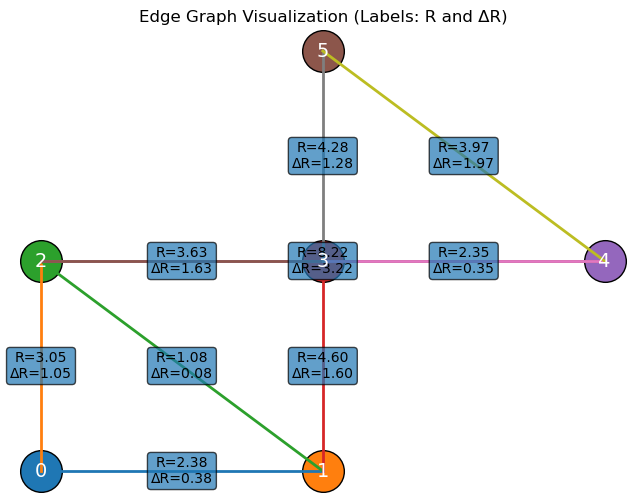

In [18]:
#  for visualization only 

import matplotlib.pyplot as plt

# ---- 1) fixed coordinates for nodes (you can change) ----
pos = {
    0: (0, 0),
    1: (2, 0),
    2: (0, 2),
    3: (2, 2),
    4: (4, 2),
    5: (2, 4),
}

plt.figure(figsize=(8, 6))

# ---- 2) draw edges (avoid drawing undirected edges twice) ----
drawn = set()

for u in edge_graph:
    for v, e in edge_graph[u].items():
        if (v, u) in drawn:
            continue
        drawn.add((u, v))

        x1, y1 = pos[u]
        x2, y2 = pos[v]

        # draw the edge line
        plt.plot([x1, x2], [y1, y2], linewidth=2)

        # midpoint for label
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2

        # label: show R and ΔR
        label = f"R={e.R:.2f}\nΔR={e.delta_R():.2f}"

        plt.text(
            mx, my, label,
            ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", alpha=0.7)
        )

# ---- 3) draw nodes ----
for node, (x, y) in pos.items():
    plt.scatter(x, y, s=900, edgecolors="black")
    plt.text(x, y, str(node), ha="center", va="center", fontsize=14, color="white")

plt.title("Edge Graph Visualization (Labels: R and ΔR)")
plt.axis("off")
plt.show()



In [20]:
#   Phase 8 Code (ACO on edge_graph with mode) 


import random

def get_edge_cost(edge, mode="R"):
    """Return the cost used by ACO depending on mode."""
    if mode == "distance":
        return edge.d
    elif mode == "R":
        return edge.R
    else:
        raise ValueError("mode must be 'distance' or 'R'")

def ant_colony_optimize_edgegraph(edge_graph, start, goal,
                                 alpha=1.0, beta=2.0, rho=0.1,
                                 num_ants=10, iterations=30,
                                 mode="R"):
    """
    ACO for shortest path from start to goal on edge_graph.
    mode='distance' uses edge.d
    mode='R' uses edge.R (road condition factor)
    """

    # initialize pheromone τ on each directed edge
    tau = {}
    for u in edge_graph:
        for v in edge_graph[u]:
            tau[(u, v)] = 1.0

    best_path = None
    best_cost = float("inf")

    for it in range(iterations):
        paths_this_iter = []

        for k in range(num_ants):
            current = start
            visited = {start}
            path = [start]
            total_cost = 0.0

            while current != goal:
                neighbors = list(edge_graph[current].keys())
                choices = [j for j in neighbors if j not in visited]

                if not choices:
                    path = None
                    break

                # compute probabilities
                probs = []
                denom = 0.0
                for j in choices:
                    edge = edge_graph[current][j]
                    cost_ij = get_edge_cost(edge, mode=mode)

                    pher = (tau[(current, j)] ** alpha)
                    heur = ((1.0 / cost_ij) ** beta)  # η = 1/cost
                    val = pher * heur

                    probs.append((j, val))
                    denom += val

                # roulette selection
                r = random.random() * denom
                cum = 0.0
                next_node = choices[-1]
                for j, val in probs:
                    cum += val
                    if r <= cum:
                        next_node = j
                        break

                # move
                edge_used = edge_graph[current][next_node]
                total_cost += get_edge_cost(edge_used, mode=mode)
                visited.add(next_node)
                path.append(next_node)
                current = next_node

            if path is not None and current == goal:
                paths_this_iter.append((path, total_cost))
                if total_cost < best_cost:
                    best_cost = total_cost
                    best_path = path

        # pheromone evaporation
        for e in tau:
            tau[e] *= (1 - rho)

        # pheromone deposit (Q=1 here, can scale later)
        for path, cost in paths_this_iter:
            deposit = 1.0 / cost if cost > 0 else 0
            for i in range(len(path) - 1):
                u, v = path[i], path[i + 1]
                tau[(u, v)] += deposit

    return best_path, best_cost



In [22]:
#original dhaka test

In [ ]:
import requests

# Define three sample nodes by coordinates (lat,lng) in Dhaka
origins = "23.8103,90.4125|23.7765,90.3995|23.7073,90.4155"  # e.g., Gulshan, Dhanmondi, Old Dhaka (lat,long)
destinations = origins  # We want a full matrix between these same points
api_key = "YOUR_API_KEY"  # replace with your actual API key

# Prepare API request URL (JSON output by default)
url = f"https://maps.googleapis.com/maps/api/distancematrix/json?origins={origins}&destinations={destinations}&departure_time=now&key={api_key}"

response = requests.get(url)
data = response.json()

# List of node labels for clarity (corresponding to the coordinates above)
nodes = ["Location1", "Location2", "Location3"]

# Initialize graph as an empty dictionary
graph = {node: {} for node in nodes}

# Fill the graph with travel time (seconds) for each origin-destination pair
for i, origin in enumerate(nodes):
    for j, dest in enumerate(nodes):
        # Get travel time from origin i to destination j
        element = data['rows'][i]['elements'][j]
        if element.get('duration_in_traffic'):
            travel_time = element['duration_in_traffic']['value']  # in seconds
        else:
            travel_time = element['duration']['value']  # fallback to duration if no traffic info
        graph[origin][dest] = travel_time

# Example: print travel time from Location1 to Location3
print(f"Travel time from {nodes[0]} to {nodes[2]}: {graph[nodes[0]][nodes[2]]} seconds")
